In [201]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

str_dt = '2026-01-31'
window = 3

str_dt = datetime.strptime(str_dt,'%Y-%m-%d')
end_dt = str_dt.replace(day=1) + relativedelta(months=window + 1,days=-1)

str_dt = str_dt.strftime('%Y-%m-%d')
end_dt = end_dt.strftime('%Y-%m-%d')

print('+----------  +====+  ----------+')
print('|'+str_dt +'  |====|  '+ end_dt+'|')
print('+----------  +====+  ----------+')

+----------  +====+  ----------+
|2026-01-31  |====|  2026-04-30|
+----------  +====+  ----------+


In [202]:
relativedelta(datetime.strptime(end_dt,'%Y-%m-%d'),datetime.strptime(str_dt,'%Y-%m-%d')).months + 1

4

In [204]:
import pyodbc as odbc
import pandas as pd

server='andromeda'
database='MIS_RIESGOS'
connection_string=f"""
DRIVER={{ODBC Driver 17 for SQL Server}};
SERVER={server};
DATABASE={database};
Trusted_Connection=yes;
"""

con = odbc.connect(connection_string)
cursor = con.cursor()

query=f"""
select *
from MIS_RIESGOS.GT.BASES_HISTORICAS_PTMO_TC_GS
where mis_date between '{str_dt}' and '{end_dt}'
"""

result=cursor.execute(query)

result = result.fetchall()
column_names = [column[0] for column in cursor.description]

cursor.close()
con.close()

df = pd.DataFrame.from_records(result,columns=column_names)
df.head(2)

,MIS_DATE,CODIGO_SUB_APLICACION,CODIGO_OBLIGACION,CODIGO_TIPO_CREDITO,DESC_MONEDA,MONTO_MND_ORG,APERTURA,VENCIMIENTO,TASA_TOTAL,BL_Dias_de_Mora,TIPO_BASE,SEGMENTO,DESC_SUB_APLICACION,FECHA_CIERRE,CLASIFICACION,TOTAL_DEUDA
0,2026-01-31,441.0,0000044100446488179,2.0,QUETZALES,0.0,2018-09-11,2022-09-30,0.0,0,TC_V+,Quetzal - Consumo - Tarjeta de Crédito,TARJETA DE CREDITO,2026-01-31,1,0.0
1,2026-01-31,423.0,0000042300480023526,2.0,QUETZALES,8556.0,2019-09-20,2029-12-31,0.0,0,TC_V+,Quetzal - Consumo - Prestamo - Ficocrédito,FICOCREDITO (TELEFONICO) M/N,2026-01-31,1,8556.0


In [205]:
df.groupby(by=['MIS_DATE']).agg(conteo=('MIS_DATE','size')).reset_index()

,MIS_DATE,conteo
0,2026-01-31,366648
1,2026-02-28,368068
2,2026-03-31,369808
3,2026-04-30,374446


In [206]:
path = r'C:\Users\HN34064\Documents\2026\6. Junio\3. PD Guatemala\Data\Detalle'
path = path.replace('\\','/')
df.to_csv(path+'/year_5.4.csv', index=False, header=True)

In [208]:
import duckdb

result = duckdb.query(f"""
select MIS_DATE, count(1) as conteo
from read_csv_auto('{path}/*.csv')
group by MIS_DATE
""").fetchdf()


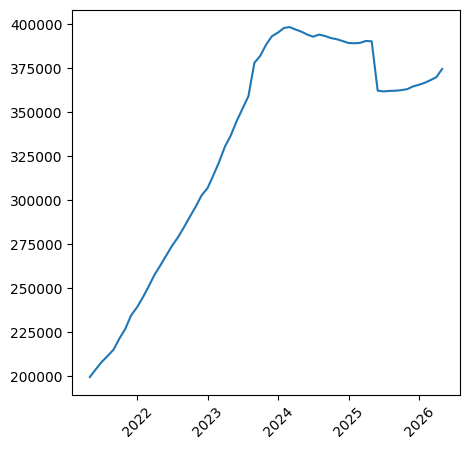

In [222]:
result.sort_values(by=['MIS_DATE'], ascending=True, inplace=True)
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(5,5))
ax.plot(result.set_index('MIS_DATE'))

plt.xticks(rotation=45)
plt.show()

In [217]:
result.set_index('MIS_DATE').loc['2024-12-31':]

,conteo
MIS_DATE,
2024-12-31,389213
2025-01-31,389086
2025-02-28,389281
2025-03-31,390393
2025-04-30,390176
2025-05-31,362151
2025-06-30,361700
2025-07-31,361988
2025-08-31,362087


In [218]:
result.shape

(61, 2)